# 1. Getting Started with PA3Py

In this notebook, we will learn how to initialize `PA3Py`, run a growth simulation for an embryo, and plot the results.

In [1]:
import sys
import os
import matplotlib.pyplot as plt

# Add package path (if running from the local repository)
sys.path.insert(0, os.path.abspath('../../src'))
from pa3py import PA3Py
from pa3py import constants as c

## Initializing the Simulation

We load the simulation simply by passing the path of our HDF5 disk output to the main `PA3Py` class.

In [2]:
# Path to your TripodPy HDF5 data
data_path = '../../tests/test_data/run_smooth_a0.001_v10'

# Initialize the engine
sim = PA3Py(data_path)

[load_tripodpy_hdf5] Leyendo 100 snapshots desde ../../tests/test_data/run_smooth_a0.001_v10...


## Running Growth

We will tell `PA3Py` to compute the growth for an embryo located at 3 AU, with an initial seed mass of $10^{-3} M_\oplus$.

In [3]:
# Embryos to simulate
embryos = [3.0]

# Execute the module
results = sim.run_growth(embryos, m_seed_me=1e-3)


-------------------------------------------------------------
  r [AU]  M_tot [ME]  M_iso [ME]  f_silicates[%]  f_H2O[%]
-------------------------------------------------------------
    3.00        9.016         9.02            50.0      50.0
-------------------------------------------------------------



## Plotting Mass Evolution

The `results` dictionary contains arrays where the first column is time (in seconds) and the second is the total mass of the embryo.

<>:13: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:13: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
C:\Users\Maxlo\AppData\Local\Temp\ipykernel_23404\35467322.py:13: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
  plt.ylabel("Mass [M_\oplus]")


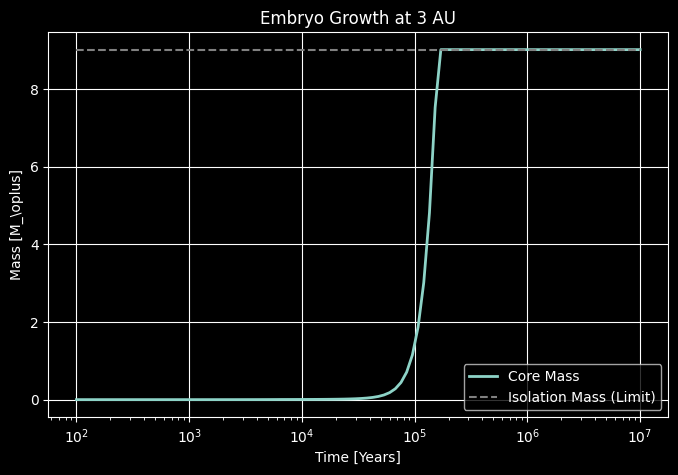

In [4]:
# Extract data for the embryo at 3 AU
history_3au = results[3.0]

time_years = history_3au[:, 0] / (3.154e7)  # Convert s to years
total_mass = history_3au[:, 1] / c.M_EARTH # Convert to Earth Masses
iso_mass = history_3au[:, 2] / c.M_EARTH


plt.figure(figsize=(8,5))
plt.plot(time_years, total_mass, lw=2, label="Core Mass")
plt.plot(time_years, iso_mass, '--', color='gray', label="Isolation Mass (Limit)")
plt.xlabel("Time [Years]")
plt.ylabel("Mass [M_\oplus]")
plt.xscale("log")
plt.title("Embryo Growth at 3 AU")
plt.legend()
plt.grid(True)
plt.show()

## Water Mass Fraction

By default, PA3Py runs the classic `silicates` and `H2O` model by tracking the dynamic snowline position.
We can extract the water mass (column 4) and see how the fraction increased.

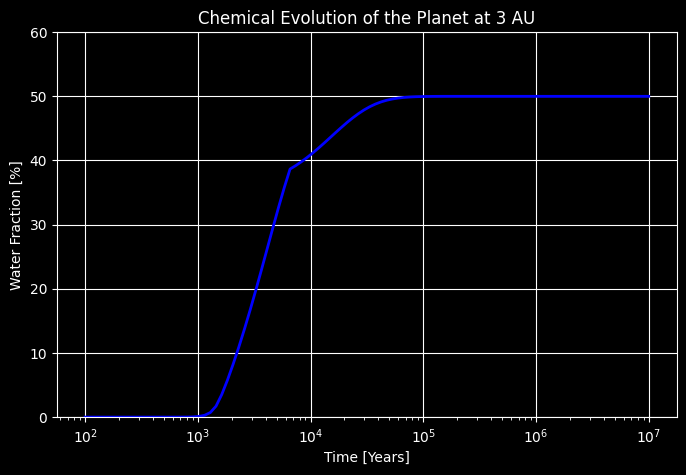

In [5]:
silicate_mass = history_3au[:, 3]
water_mass = history_3au[:, 4]
total_mass_sum = silicate_mass + water_mass

water_fraction = 100 * water_mass / total_mass_sum

plt.figure(figsize=(8,5))
plt.plot(time_years, water_fraction, color='blue', lw=2)
plt.xscale("log")
plt.xlabel("Time [Years]")
plt.ylabel("Water Fraction [%]")
plt.title("Chemical Evolution of the Planet at 3 AU")
plt.ylim(0, 60)
plt.grid(True)
plt.show()